In [1]:
import pandas as pd

df = pd.read_parquet('../data/raw/yellow_tripdata_2025-04.parquet')

In [2]:
df.shape

(3970553, 20)

In [3]:
df.sample(3)

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,cbd_congestion_fee
336639,2,2025-04-03 23:02:16,2025-04-03 23:26:15,1.0,4.33,1.0,N,161,87,1,24.0,1.00,0.5,5.95,0.0,1.0,35.70,2.5,0.0,0.75
660012,1,2025-04-07 01:39:03,2025-04-07 02:03:43,0.0,10.50,1.0,N,162,95,1,43.6,4.25,0.5,9.85,0.0,1.0,59.20,2.5,0.0,0.75
844264,2,2025-04-08 19:51:17,2025-04-08 20:03:58,1.0,0.99,1.0,N,186,230,1,12.1,2.50,0.5,3.87,0.0,1.0,23.22,2.5,0.0,0.75


In [4]:
df.isna().sum()

VendorID                      0
tpep_pickup_datetime          0
tpep_dropoff_datetime         0
passenger_count          745730
trip_distance                 0
RatecodeID               745730
store_and_fwd_flag       745730
PULocationID                  0
DOLocationID                  0
payment_type                  0
fare_amount                   0
extra                         0
mta_tax                       0
tip_amount                    0
tolls_amount                  0
improvement_surcharge         0
total_amount                  0
congestion_surcharge     745730
Airport_fee              745730
cbd_congestion_fee            0
dtype: int64

In [5]:
# ЧАСТЬ 1: ПРОПУСКИ И ДУБЛИКАТЫ
# строки с хотя бы одним NaN — это ровно те же строки, где payment_type == 0

df.index[df.isna().any(axis=1)].equals(df.index[df["payment_type"] == 0])

True

In [6]:
df[df.duplicated()].shape

(0, 20)

In [7]:
# ЧАСТЬ 2: МИНИМАЛЬНАЯ ОЧИСТКА ДАННЫХ
mask_1 = df["tpep_pickup_datetime"] > df["tpep_dropoff_datetime"]
mask_2 = (df["tpep_pickup_datetime"] == df["tpep_dropoff_datetime"]) & (df['trip_distance'] != 0)
mask_3 = (df["tpep_pickup_datetime"] < '2025-04-01') | (df["tpep_pickup_datetime"] >= '2025-05-01')
df[mask_1 | mask_2 | mask_3]

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,cbd_congestion_fee
5,7,2025-04-01 00:39:00,2025-04-01 00:39:00,1.0,0.95,1.0,N,233,164,1,5.8,0.0,0.5,0.00,0.00,1.0,11.55,2.5,0.00,0.75
46,7,2025-04-01 00:25:00,2025-04-01 00:25:00,1.0,2.04,1.0,N,239,230,2,12.1,0.0,0.5,0.00,0.00,1.0,17.85,2.5,0.00,0.75
176,2,2025-03-31 23:45:01,2025-03-31 23:54:54,1.0,1.86,1.0,N,43,164,1,12.1,1.0,0.5,3.57,0.00,1.0,21.42,2.5,0.00,0.75
322,7,2025-04-01 00:04:00,2025-04-01 00:04:00,1.0,0.68,1.0,N,142,163,2,6.5,0.0,0.5,0.00,0.00,1.0,12.25,2.5,0.00,0.75
343,7,2025-04-01 00:31:00,2025-04-01 00:31:00,1.0,9.52,1.0,N,138,48,1,40.8,0.0,0.5,12.05,6.94,1.0,72.29,2.5,6.75,0.75
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3956173,6,2025-04-30 13:04:53,2025-04-30 13:04:11,NaN,3.46,NaN,None,139,191,0,0.0,0.0,0.5,0.00,0.00,0.3,16.39,NaN,NaN,0.00
3956174,6,2025-04-30 13:04:28,2025-04-30 13:04:12,NaN,4.12,NaN,None,191,218,0,2.9,0.0,0.5,0.00,0.00,0.3,20.31,NaN,NaN,0.00
3957103,6,2025-04-30 15:04:56,2025-04-30 15:04:01,NaN,2.01,NaN,None,45,33,0,2.9,0.0,0.5,0.00,0.00,0.3,0.00,NaN,NaN,0.00
3957243,6,2025-04-30 15:04:51,2025-04-30 15:04:06,NaN,1.01,NaN,None,151,238,0,2.9,0.0,0.5,0.00,0.00,0.3,16.00,NaN,NaN,0.00


In [8]:
# проблемных строк 33940, значительно больше, чем было ранее
# 33940 записей составляет ~0.85% от размера всей выборки, удалим эти записи
df = df[~(mask_1 | mask_2 | mask_3)]

In [9]:
# проверяю PULocationID, DOLocationID
zones = pd.read_csv("../data/raw/taxi_zone_lookup.csv")
valid_ids = set(zones["LocationID"])
print('записей с несуществующими зонами посадки:', df[~(df["PULocationID"].isin(valid_ids))].shape[0])
print('записей с несуществующими зонами высадки:', df[~(df["DOLocationID"].isin(valid_ids))].shape[0])

записей с несуществующими зонами посадки: 0
записей с несуществующими зонами высадки: 0


In [10]:
df[df["PULocationID"] == 264]

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,cbd_congestion_fee
44,1,2025-04-01 00:02:36,2025-04-01 00:17:12,1.0,6.50,1.0,N,264,264,1,26.8,1.00,0.5,5.85,0.00,1.0,35.15,0.0,0.0,0.00
1053,1,2025-04-01 00:07:07,2025-04-01 00:29:38,1.0,5.60,1.0,N,264,264,2,28.9,4.25,0.5,0.00,0.00,1.0,34.65,2.5,0.0,0.75
1067,1,2025-04-01 00:52:58,2025-04-01 01:19:51,1.0,12.20,1.0,N,264,13,1,47.8,4.25,0.5,5.36,0.00,1.0,58.91,2.5,0.0,0.75
1360,2,2025-04-01 00:23:42,2025-04-01 00:59:06,1.0,17.49,2.0,N,264,230,1,70.0,0.00,0.5,16.34,6.94,1.0,98.03,2.5,0.0,0.75
1549,2,2025-04-01 01:12:52,2025-04-01 01:28:55,1.0,3.90,1.0,N,264,264,1,19.8,1.00,0.5,5.11,0.00,1.0,30.66,2.5,0.0,0.75
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3959511,1,2025-04-30 17:50:33,2025-04-30 18:11:33,NaN,1.60,NaN,None,264,264,0,18.4,2.50,0.5,5.13,0.00,1.0,30.78,NaN,NaN,0.75
3961106,1,2025-04-30 18:22:51,2025-04-30 18:29:56,NaN,1.40,NaN,None,264,264,0,9.3,2.50,0.5,1.58,0.00,1.0,17.38,NaN,NaN,0.00
3961560,1,2025-04-30 18:02:29,2025-04-30 18:08:23,NaN,1.10,NaN,None,264,264,0,8.6,2.50,0.5,2.26,0.00,1.0,17.36,NaN,NaN,0.00
3963426,1,2025-04-30 19:39:54,2025-04-30 19:53:17,NaN,1.00,NaN,None,264,233,0,12.1,2.50,0.5,3.87,0.00,1.0,23.22,NaN,NaN,0.75


In [11]:
# записей с зоной 264 всего 7336, удаляю их
df = df[df["PULocationID"] != 264]

In [12]:
# ЧАСТЬ 3: EDA
print('удалено записей из таблицы:', 3970553-df.shape[0])
print('осталось записей о поездке:', df.shape[0])
print('максимальная и минимальная даты в таблице:', df['tpep_pickup_datetime'].max(), df['tpep_pickup_datetime'].min())

удалено записей из таблицы: 41276
осталось записей о поездке: 3929277
максимальная и минимальная даты в таблице: 2025-04-30 23:59:59 2025-04-01 00:00:00


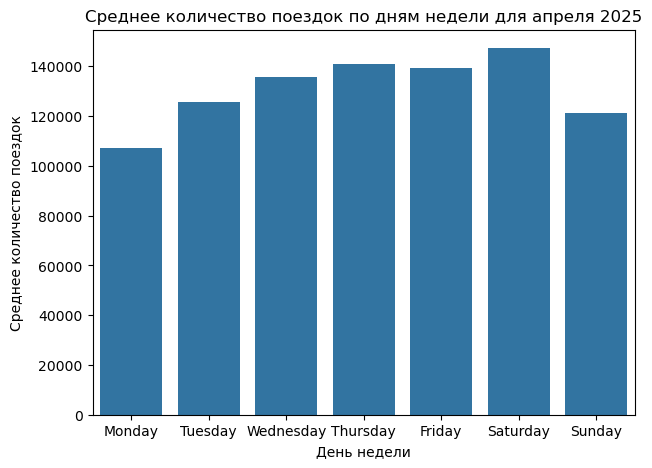

In [13]:
# рассмотрим распределение записей по дням недели (считая для начала поездки) и визуализируем
import seaborn as sns
import matplotlib.pyplot as plt


plt.figure(figsize=(7, 5))
first_group = df.groupby(df['tpep_pickup_datetime'].dt.date).size()
weekday_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]
second_group = first_group.groupby(pd.to_datetime(first_group.index).day_name()).mean()
second_group = second_group.reindex(weekday_order)
sns.barplot(data=second_group).set(title='Среднее количество поездок по дням недели для апреля 2025',
                                   xlabel='День недели',
                                   ylabel='Среднее количество поездок');

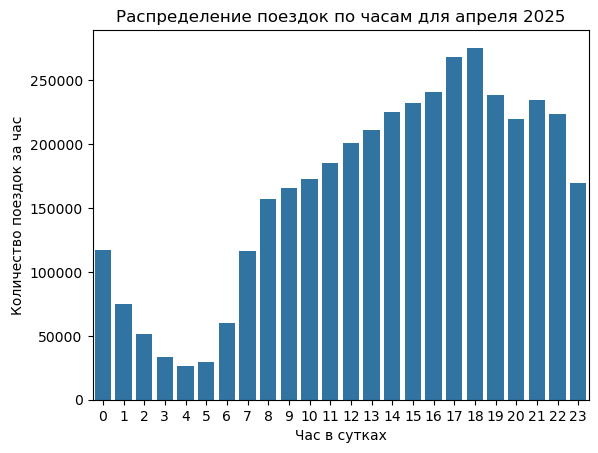

In [14]:
# рассмотрим распределение записей по часам и визуализируем
gr = df.groupby(df['tpep_pickup_datetime'].dt.hour).size()
sns.barplot(data=gr).set(
    title='Распределение поездок по часам для апреля 2025', 
    xlabel='Час в сутках', 
    ylabel='Количество поездок за час');

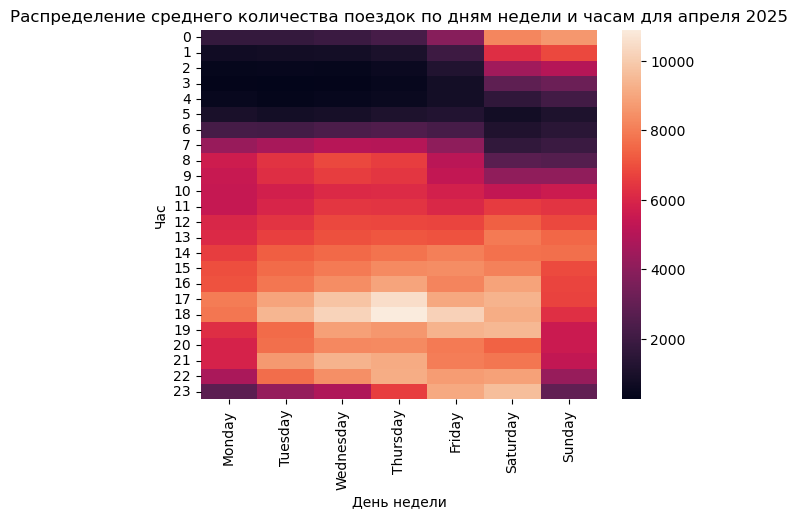

In [15]:
# Посмотрим среднее количество поездок по дню недели и часу
day_hour = df.groupby([
    df["tpep_pickup_datetime"].dt.date.rename("date"), 
    df["tpep_pickup_datetime"].dt.day_name().rename("day_of_week"), 
    df["tpep_pickup_datetime"].dt.hour.rename("hour")]).size().rename("trips")
day_hour = day_hour.reset_index()

day_hour = day_hour.groupby([
    day_hour["day_of_week"],
    day_hour["hour"]])["trips"].mean()
day_hour = day_hour.reset_index()


day_hour = day_hour.pivot(columns="day_of_week", index="hour", values="trips")
day_hour = day_hour[weekday_order]

sns.heatmap(day_hour).set(title="Распределение среднего количества поездок по дням недели и часам для апреля 2025", 
                          xlabel="День недели", 
                          ylabel="Час");

In [16]:
# Среднее количество поездок в пятницу вернулось к прежнему уровню по сравнению с мартовским графиком.
# Распределение по часам немного изменилось, понизились значения для 19 и 20 часов.
# Хитмап для распределения 'день недели x час' тоже в целом похож, но имеет малые отклонения:
# спрос в субботу вечером вернулся к уровню февраля, пик активности - четверг в 18.

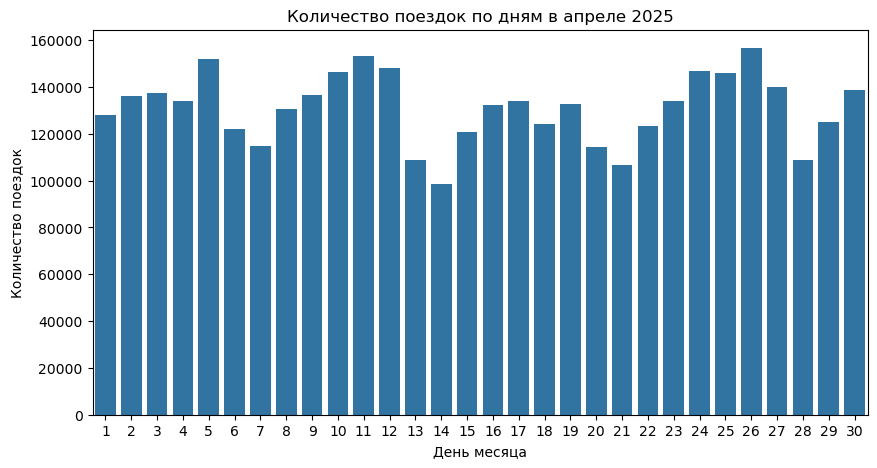

In [18]:
# Рассмотрим спрос на такси в конкретные даты

from datetime import date


gr_date = df.groupby(df["tpep_pickup_datetime"].dt.date.rename("date")).size().rename("trips")
gr_date = gr_date.to_frame()

gr_date = gr_date.reset_index()
gr_date["date"] = pd.to_datetime(gr_date["date"])
gr_date["date"] = gr_date["date"].dt.day

plt.figure(figsize=(10, 5))
sns.barplot(data=gr_date, x="date", y="trips").set(
    title="Количество поездок по дням в апреле 2025", 
    xlabel="День месяца", 
    ylabel="Количество поездок");

# Паттерн прошлых месяцев сохраняется .
# Особенно низкие значения наблюдаются по понедельникам: 7, 14, 21, 28 числа.

In [19]:
# Зона посадки PULocationID

start_zone_borough = df.groupby(df["PULocationID"]).size().rename("trips")
start_zone_borough = start_zone_borough.to_frame()
start_zone_borough = start_zone_borough.merge(zones[["LocationID", "Borough", "Zone"]], left_index=True, right_on='LocationID')
start_zone_borough = start_zone_borough.set_index("LocationID")
start_borough = start_zone_borough.groupby(start_zone_borough["Borough"])["trips"].sum().sort_values()
start_borough = start_borough.to_frame()
start_borough
# ожидаемо, поездки на жёлтых такси всё так же преобладают на Манхэттене

,trips
Borough,
Staten Island,347
EWR,473
Bronx,29874
Brooklyn,126085
Queens,360553
Manhattan,3410311


In [20]:
# ЧАСТЬ 4: ИСКОМЫЕ ДАННЫЕ
venue_zone_ids = [79, 161, 163, 186, 239]

df_selected = df[
    df["PULocationID"].isin(venue_zone_ids)
]

data_pickup = (
    df_selected
    .groupby([
        df_selected["tpep_pickup_datetime"].dt.floor("D").rename("date"),
        df_selected["tpep_pickup_datetime"].dt.hour.rename("hour"),
        df_selected["PULocationID"].rename("LocationID")
    ])
    .size()
    .rename("pickups")
    .reset_index()
)

data_pickup

,date,hour,LocationID,pickups
0,2025-04-01,0,79,57
1,2025-04-01,0,161,80
2,2025-04-01,0,163,53
3,2025-04-01,0,186,110
4,2025-04-01,0,239,32
...,...,...,...,...
3591,2025-04-30,23,79,223
3592,2025-04-30,23,161,223
3593,2025-04-30,23,163,181
3594,2025-04-30,23,186,129


In [21]:
# В таблице должно быть 30 дней x 24 часа x 5 зон = 3600 записей,
# сейчас в таблице 3596 записей, пропуск строки значит, что в этот день, в этот час, в этом районе
# не было ни одной поездки на такси. Найдём такие записи и запишем для них 0 в pickups

full_index = pd.MultiIndex.from_product(
    [
        pd.date_range("2025-04-01", "2025-04-30", freq="D"),
        range(24),
        venue_zone_ids
    ],
    names=["date", "hour", "LocationID"]
)

data_pickup = (
    data_pickup
    .set_index(["date", "hour", "LocationID"])
    .reindex(full_index, fill_value=0)
    .reset_index()
)

assert (
    data_pickup["pickups"].sum()
    ==
    df["PULocationID"].isin(venue_zone_ids).sum()
)

data_pickup

,date,hour,LocationID,pickups
0,2025-04-01,0,79,57
1,2025-04-01,0,161,80
2,2025-04-01,0,163,53
3,2025-04-01,0,186,110
4,2025-04-01,0,239,32
...,...,...,...,...
3595,2025-04-30,23,79,223
3596,2025-04-30,23,161,223
3597,2025-04-30,23,163,181
3598,2025-04-30,23,186,129


In [22]:
# ЧАСТЬ 5: СОХРАНЕНИЕ ОБРАБОТАННЫХ ДАННЫХ

from pathlib import Path

processed_taxi_dir = Path("../data/processed/taxi")
processed_taxi_dir.mkdir(parents=True, exist_ok=True)

output_path = (
    processed_taxi_dir
    / "yellow_taxi_pickups_2025_04.parquet"
)

data_pickup.to_parquet(
    output_path,
    index=False
)

In [23]:
data_pickup_check = pd.read_parquet(output_path)

print("Размер:", data_pickup_check.shape)
print(
    "Дубликаты:",
    data_pickup_check.duplicated(
        subset=["date", "hour", "LocationID"]
    ).sum()
)
print("Пропуски:", data_pickup_check.isna().sum().sum())
print("Количество зон:", data_pickup_check["LocationID"].nunique())

assert data_pickup_check.equals(data_pickup)

Размер: (3600, 4)
Дубликаты: 0
Пропуски: 0
Количество зон: 5
